In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [1]:
import os
import shutil
import matplotlib.pyplot as plt
import random

def prepare_full_dataset_for_flow(train_dir_original, test_dir_original, target_base_dir, val_percent=0.2):
    train_dir = os.path.join(target_base_dir, 'train')
    validation_dir = os.path.join(target_base_dir, 'validation')
    test_dir = os.path.join(target_base_dir, 'test')

    if not os.path.exists(target_base_dir):
        os.mkdir(target_base_dir)
        os.mkdir(train_dir)
        os.mkdir(validation_dir)
        os.mkdir(test_dir)
        for c in ['dogs', 'cats']:
            os.mkdir(os.path.join(train_dir, c))
            os.mkdir(os.path.join(validation_dir, c))
        os.mkdir(os.path.join(test_dir, 'images'))
        print('created the required directory structure')

        files = os.listdir(train_dir_original)
        train_files = [os.path.join(train_dir_original, f) for f in files]
        random.shuffle(train_files)
        n = int(len(train_files) * val_percent)
        val = train_files[:n]
        train = train_files[n:]

        for t in train:
            if 'cat' in t:
                shutil.copy2(t, os.path.join(train_dir, 'cats'))
            else:
                shutil.copy2(t, os.path.join(train_dir, 'dogs'))

        for v in val:
            if 'cat' in v:
                shutil.copy2(v, os.path.join(validation_dir, 'cats'))
            else:
                shutil.copy2(v, os.path.join(validation_dir, 'dogs'))
        files = os.listdir(test_dir_original)
        test_files = [os.path.join(test_dir_original, f) for f in files]
        for t in test_files:
            shutil.copy2(t, os.path.join(test_dir, 'images'))
    else:
        print('required directory structure already exists. learning continues with existing data')

    nb_train_samples = 0
    nb_validation_samples = 0
    for c in ['dogs', 'cats']:
        nb_train_samples = nb_train_samples + len(os.listdir(os.path.join(train_dir, c)))
    print('total training images:', nb_train_samples)
    for c in ['dogs', 'cats']:
        nb_validation_samples = nb_validation_samples + len(os.listdir(os.path.join(validation_dir, c)))
    print('total validation images:', nb_validation_samples)
    nb_test_samples = len(os.listdir(os.path.join(test_dir, 'images')))
    print('total test images:', nb_test_samples )

    return train_dir, validation_dir, test_dir, nb_train_samples, nb_validation_samples, nb_test_samples

def prepare_small_dataset_for_flow(train_dir_original, test_dir_original, target_base_dir):
    train_dir = os.path.join(target_base_dir, 'train')
    validation_dir = os.path.join(target_base_dir, 'validation')
    test_dir = os.path.join(target_base_dir, 'test')

    if not os.path.exists(target_base_dir):
        os.mkdir(target_base_dir)
        os.mkdir(train_dir)
        os.mkdir(validation_dir)
        os.mkdir(test_dir)
        for c in ['dogs', 'cats']:
            os.mkdir(os.path.join(train_dir, c))
            os.mkdir(os.path.join(validation_dir, c))
        os.mkdir(os.path.join(test_dir, 'images'))
        print('created the required directory structure')

        train_cats = ['cat.{}.jpg'.format(i) for i in range(1000)]
        for t in train_cats:
             shutil.copy2(os.path.join(train_dir_original, t), os.path.join(train_dir, 'cats'))
        train_dogs = ['dog.{}.jpg'.format(i) for i in range(1000)]
        for t in train_dogs:
             shutil.copy2(os.path.join(train_dir_original, t), os.path.join(train_dir, 'dogs'))
        val_cats = ['cat.{}.jpg'.format(i) for i in range(1000, 1500)]
        for t in val_cats:
             shutil.copy2(os.path.join(train_dir_original, t), os.path.join(validation_dir, 'cats'))
        val_dogs = ['dog.{}.jpg'.format(i) for i in range(1000, 1500)]
        for t in val_dogs:
             shutil.copy2(os.path.join(train_dir_original, t), os.path.join(validation_dir, 'dogs'))

        files = os.listdir(test_dir_original)
        test_files = [os.path.join(test_dir_original, f) for f in files]
        for t in test_files:
            shutil.copy2(t, os.path.join(test_dir, 'images'))
    else:
        print('required directory structure already exists. learning continues with existing data')

    nb_train_samples = 0
    nb_validation_samples = 0
    for c in ['dogs', 'cats']:
        nb_train_samples = nb_train_samples + len(os.listdir(os.path.join(train_dir, c)))
    print('total training images:', nb_train_samples)
    for c in ['dogs', 'cats']:
        nb_validation_samples = nb_validation_samples + len(os.listdir(os.path.join(validation_dir, c)))
    print('total validation images:', nb_validation_samples)
    nb_test_samples = len(os.listdir(os.path.join(test_dir, 'images')))
    print('total test images:', nb_test_samples )

    return train_dir, validation_dir, test_dir, nb_train_samples, nb_validation_samples, nb_test_samples

In [2]:
mkdir -p ~/.kaggle && echo KGAT_6b26e673b17306239bfd24c6431c2325 > ~/.kaggle/access_token && chmod 600 ~/.kaggle/access_token

In [29]:
!kaggle competitions download -c dogs-vs-cats-redux-kernels-edition

100% 4.00G/4.00G [01:50<00:00, 38.8MB/s]



In [4]:
!unzip /content/dogs-vs-cats-redux-kernels-edition.zip

Archive:  /content/dogs-vs-cats-redux-kernels-edition.zip
  inflating: sample_submission.csv   
  inflating: test.zip                
  inflating: train.zip               


In [ ]:
!unzip /content/test.zip
!unzip /content/train.zip

In [6]:
#from keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.models import Sequential #For Sequential/Feed Forward Neural Net
#CNN based models require Conv2D, MaxPooling2D
from keras.layers import Conv2D, MaxPooling2D
#FFNN requires Flatten, Dense
from keras.layers import Flatten, Dense
from keras import backend as K
#import collections
import os
import pandas as pd

#import utils
#Early stopping is required when systme realizes that there is no improvement after ceratin epochs
from keras.callbacks import ModelCheckpoint, EarlyStopping
#import PIL.Image
os.getcwd()

from google.colab import drive
#drive.mount('/content/drive')
os.chdir('/content')

train_dir, validation_dir, test_dir, nb_train_samples, nb_validation_samples,nb_test_samples = \
                            prepare_full_dataset_for_flow(
                            train_dir_original='train',
                            test_dir_original='test',
                            target_base_dir='target')


#Convert all images to standard width and height
img_width, img_height = 150, 150
epochs = 3
batch_size = 20

created the required directory structure
total training images: 20000
total validation images: 5000
total test images: 12500


In [7]:
#from keras.applications.inception_v3 import InceptionV3
#from keras.applications.vgg16 import VGG16
#from keras.applications.densenet import DenseNet169
#from keras.applications.resnet50 import ResNet50

#Channels first is for Tensorflow for input shape
if K.image_data_format() == 'channels_first':
    input_shape = (3, img_width, img_height)
else: #For non Tensorflow the imput shape is different
    input_shape = (img_width, img_height, 3)

model = Sequential()
#CNN modedl with 32 filter and the filter size of 3X3 and stride as 1 and padding as 0
model.add(Conv2D(32, (3, 3), activation='relu',input_shape=(input_shape)))
model.add(MaxPooling2D((2, 2)))

#2nd level CNN
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))

#3rd levle CNN
model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))

model.add(Flatten())
#So far fetures got extracted by using CNN and Max Pooling

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
#Next apply FFNN to classify
model.add(Dense(512, activation='sigmoid'))
model.add(Dense(256, activation='sigmoid')) #Hidden Layer
#2 outputs (Cats Vs Daogs)
#softmax normalizes the probability Bcoz in the Sigmoid the probability may NOT become Zero.
#Softmax ensures the sum(probablity) must be Zero.
model.add(Dense(2, activation='softmax'))
print(model.summary())
#-------------------------
model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    18,940,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,165,506 (73.11 MB)

 Trainable params: 19,165,506 (73.11 MB)

 Non-trainable params: 0 (0.00 B)

None


In [9]:
#Data Augmentation (New Data Generation/Transofrmation of data)
#Overfitting can be addressed with Data Augmentation
train_datagen = ImageDataGenerator(
        rescale=1./255,
        rotation_range=40,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True,
        fill_mode='nearest')
#If we want, you can write all these Augmented data into new files
validation_datagen = ImageDataGenerator(rescale=1. / 255)

Print Augemented Data for 1 image

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt

# Assuming you have an image tensor 'original_image' and an augmentation layer 'data_augmentation'
# Example:
original_image = tf.io.read_file("/content/train/dog.1.jpg")
original_image = tf.image.decode_jpeg(original_image)
original_image = tf.image.resize(original_image, (150, 150))

# Define your data augmentation layers
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.CenterCrop( 100, 100),
    tf.keras.layers.RandomZoom(0.1),
])

# Apply augmentation
augmented_image = data_augmentation(original_image)

# Display original and augmented images
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(original_image.numpy().astype("uint8")) # Convert to NumPy array and uint8 for display
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("Augmented Image")
plt.imshow(augmented_image.numpy().astype("uint8"))
plt.axis("off")
plt.show()

In [11]:
#Scaling of images from 0-255. Redcue image intensity
#train_datagen = ImageDataGenerator(rescale=1./255) #If Re-scaling is done at Data Augmentaion, then don't do it again
#validation_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='categorical')
validation_generator = validation_datagen.flow_from_directory(
    validation_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='categorical')

Found 20000 images belonging to 2 classes.
Found 5000 images belonging to 2 classes.



**Change the run time type to GPU/TPU**

In [20]:
#If there is no change in continuos 3 epoch(patience=3: Be patient for 3 epochs), then stop early. Heuristically 3-5 is ideal.
early_stopping = EarlyStopping(monitor='val_loss', patience=3, verbose=3, mode='auto')
#Save weights in model.h5 /model.keras
save_weights = ModelCheckpoint('VijaNaar.keras', monitor='val_loss', save_best_only=True)

#history = model.fit(train_generator, steps_per_epoch=2000//batch_size, epochs=3, validation_data=validation_generator,
history = model.fit(train_generator, epochs=10, validation_data=validation_generator,
    validation_steps=1000//batch_size,
    callbacks=[early_stopping, save_weights])

#Add both accuracies and losses into historyDataFrame
historydf = pd.DataFrame(history.history, index=history.epoch)

#plot_loss_accuracy(history)

Epoch 1/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 171s 171ms/step - accuracy: 0.4952 - loss: 0.6965 - val_accuracy: 0.5130 - val_loss: 0.6928
Epoch 2/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 160s 160ms/step - accuracy: 0.4929 - loss: 0.6956 - val_accuracy: 0.5290 - val_loss: 0.6920
Epoch 3/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 157s 156ms/step - accuracy: 0.4972 - loss: 0.6951 - val_accuracy: 0.5270 - val_loss: 0.6914
Epoch 4/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 160s 160ms/step - accuracy: 0.5189 - loss: 0.6917 - val_accuracy: 0.4960 - val_loss: 0.6934
Epoch 5/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 163s 162ms/step - accuracy: 0.5538 - loss: 0.6858 - val_accuracy: 0.5760 - val_loss: 0.6839
Epoch 6/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 167s 167ms/step - accuracy: 0.5602 - loss: 0.6823 - val_accuracy: 0.5780 - val_loss: 0.6777
Epoch 7/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 203s 167ms/step - accuracy: 0.5562 - loss: 0.6830 - val_accuracy: 0.5870 - val_loss: 0.6733
Epoch 8/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 159s 159ms/step - ac

Print intermediate response of the model

In [24]:
import numpy as np
import random
from tensorflow.keras.preprocessing.image import img_to_array, load_img

# Let's define a new Model that will take an image as input, and will output
# intermediate representations for all layers in the previous model after
# the first.
successive_outputs = [layer.output for layer in model.layers[1:]]
visualization_model = model(input_shape, successive_outputs)

# Let's prepare a random input image of a cat or dog from the training set.
cat_img_files = [os.path.join(train_cats_dir, f) for f in train_cat_fnames]
dog_img_files = [os.path.join(train_dogs_dir, f) for f in train_dog_fnames]
#Random image. We can specify exact image name also instead of Random
#img_path = tf.io.read_file("/content/train/dog.1.jpg")
img_path = random.choice(cat_img_files + dog_img_files)

img = load_img(img_path, target_size=(150, 150))  # this is a PIL image
x = img_to_array(img)  # Numpy array with shape (150, 150, 3)
x = x.reshape((1,) + x.shape)  # Numpy array with shape (1, 150, 150, 3)

# Rescale by 1/255
x /= 255

# Let's run our image through our network, thus obtaining all
# intermediate representations for this image.
successive_feature_maps = visualization_model.predict(x)

# These are the names of the layers, so can have them as part of our plot
layer_names = [layer.name for layer in model.layers[1:]]

# Now let's display our representations
for layer_name, feature_map in zip(layer_names, successive_feature_maps):
  if len(feature_map.shape) == 4:
    # Just do this for the conv / maxpool layers, not the fully-connected layers
    n_features = feature_map.shape[-1]  # number of features in feature map
    # The feature map has shape (1, size, size, n_features)
    size = feature_map.shape[1]
    # We will tile our images in this matrix
    display_grid = np.zeros((size, size * n_features))
    for i in range(n_features):
      # Postprocess the feature to make it visually palatable
      x = feature_map[0, :, :, i]
      x -= x.mean()
      x /= x.std()
      x *= 64
      x += 128
      x = np.clip(x, 0, 255).astype('uint8')
      # We'll tile each filter into this big horizontal grid
      display_grid[:, i * size : (i + 1) * size] = x
    # Display the grid
    scale = 20. / n_features
    plt.figure(figsize=(scale * n_features, scale))
    plt.title(layer_name)
    plt.grid(False)
    plt.imshow(display_grid, aspect='auto', cmap='viridis')

ValueError: Only input tensors may be passed as positional arguments. The following argument value should be passed as a keyword argument: 150 (of type <class 'int'>)

Print Accuracies and Losses in a plot for easy representation

Text(0.5, 1.0, 'Training and validation loss')

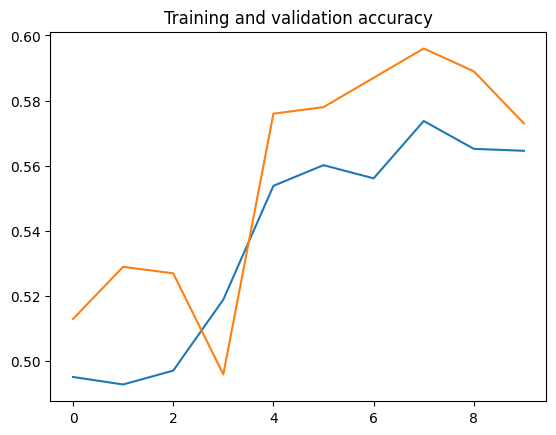

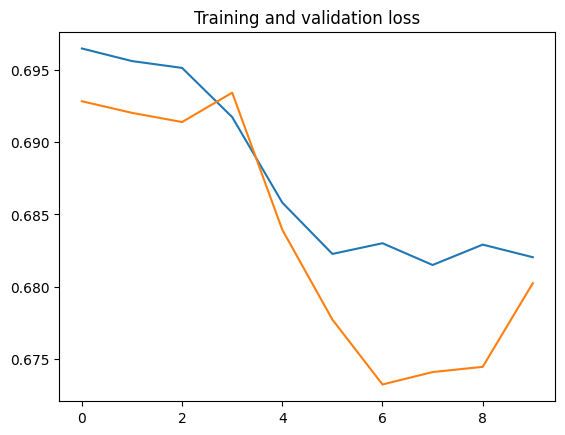

In [21]:
# Retrieve a list of accuracy results on training and validation data
# sets for each training epoch
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

# Retrieve a list of list results on training and validation data
# sets for each training epoch
loss = history.history['loss']
val_loss = history.history['val_loss']

# Get number of epochs
epochs = range(len(acc))

# Plot training and validation accuracy per epoch
plt.plot(epochs, acc)
plt.plot(epochs, val_acc)
plt.title('Training and validation accuracy')

plt.figure()

# Plot training and validation loss per epoch
plt.plot(epochs, loss)
plt.plot(epochs, val_loss)
plt.title('Training and validation loss')

In [22]:
#Now let's apply our model onto Test data
test_datagen = ImageDataGenerator(rescale=1. / 255)
test_generator = test_datagen.flow_from_directory(
        test_dir,
        target_size=(img_width, img_height),
        batch_size=batch_size,
        class_mode=None,
        shuffle=False)
#print(test_generator.filenames)
probabilities = model.predict(test_generator, 40//(batch_size))
#probabilities = model.predict_generator(test_generator, nb_test_samples//(batch_size-5))

Found 12500 images belonging to 1 classes.
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 33ms/step


In [23]:
mapper = {}
i = 0
for file in test_generator.filenames:
    #print(file)
    id = int(file.split('/')[1].split('.')[0])
    mapper[id] = probabilities[i][1]
    print(mapper[id])
    i += 1

#od = collections.OrderedDict(sorted(mapper.items()))
tmp = pd.DataFrame({'id':list(mapper.keys()),'label':list(mapper.values())})
tmp.to_csv('VijaNaar462026.csv', columns=['id','label'], index=False)

0.56604356
0.47246608
0.47806218
0.57014745
0.5431812
0.42971498
0.5006096
0.4618951
0.5308926
0.57185465
0.5438593
0.4423586
0.5347428
0.5427527
0.53495824
0.54473644
0.5341499
0.5349446
0.5355199
0.53411776
0.58578086
0.52986807
0.4283137
0.5503
0.5432553
0.54363954
0.50361824
0.4406369
0.3933571
0.5349619
0.5280864
0.53055435
0.5347089
0.55877334
0.4329504
0.54115677
0.53470814
0.5736085
0.49274364
0.46781793
0.57290417
0.43299395
0.5348303
0.53470814
0.5975233
0.5347335
0.53471476
0.5824929
0.5347087
0.5401929
0.4427728
0.5160468
0.41243872
0.54383045
0.5347439
0.5347309
0.5347081
0.54381025
0.5099363
0.41225573
0.52836573
0.43539158
0.5347081
0.42839757
0.49716628
0.43118185
0.5536292
0.53473103
0.54313385
0.5347095
0.5438196
0.516984
0.53361154
0.5438344
0.5431575
0.4949018
0.5436239
0.5438342
0.43919507
0.5347081
0.51926714
0.47893775
0.5020592
0.4445707
0.53470814
0.42812595
0.5347081
0.5362261
0.4130056
0.5347165
0.55540776
0.53779626
0.54227763
0.4230779
0.45992166
0.3952735


In [ ]:
os.getcwd()

'/content'